# Notebook 15 – Before vs After Analysis


In [13]:
import pandas as pd
import numpy as np

# BEFORE: load completely raw, untouched data
df_before = pd.read_csv("hr_employee_attrition_raw.csv")
df_before.shape

(1230, 16)

## Building the "After" Dataset

Applying everything from Notebooks 4 through 14 in order: remove
duplicates, fix data types, treat outliers, standardize categories,
encode, and scale.

In [14]:
df_after = df_before.copy()

#  remove exact duplicate rows
df_after = df_after.drop_duplicates()

#  fix data types (income and tenure were stored as text)
df_after["MonthlyIncome"] = pd.to_numeric(
    df_after["MonthlyIncome"].astype(str).str.replace(" USD", "", regex=False), errors="coerce"
)
df_after["YearsAtCompany"] = pd.to_numeric(
    df_after["YearsAtCompany"].astype(str).str.replace(" yrs", "", regex=False), errors="coerce"
)

#  treat outliers, Age errors to missing, cap unrealistic commute distance
df_after.loc[(df_after["Age"] < 15) | (df_after["Age"] > 80), "Age"] = np.nan
df_after["DistanceFromHomeKM"] = df_after["DistanceFromHomeKM"].clip(upper=150)

#  standardize inconsistent category labels
df_after["Gender"] = df_after["Gender"].str.strip().str.lower().map(
    {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}
)
df_after["Department"] = df_after["Department"].str.strip().str.title()

#  fill remaining missing numeric values with the median
for col in ["Age", "JobSatisfaction", "MonthlyIncome", "YearsAtCompany"]:
    df_after[col] = df_after[col].fillna(df_after[col].median())

df_after.shape

(1210, 16)

## 1. Shape Comparison

Rows should drop slightly (duplicates removed), columns should stay the
same at this stage since we haven't one-hot encoded yet.

In [15]:
print("BEFORE shape:", df_before.shape)
print("AFTER shape:", df_after.shape)
print("Rows removed (duplicates):", df_before.shape[0] - df_after.shape[0])

BEFORE shape: (1230, 16)
AFTER shape: (1210, 16)
Rows removed (duplicates): 20


## 2. Data Types Comparison

`MonthlyIncome` and `YearsAtCompany` were stored as text because of stray
values like "USD" and "yrs" mixed into otherwise numeric columns
(Notebook 5, Notebook 9).

In [16]:
dtype_comparison = pd.DataFrame({
    "Before": df_before.dtypes.astype(str),
    "After": df_after.dtypes.astype(str)
})
dtype_comparison[dtype_comparison["Before"] != dtype_comparison["After"]]

,Before,After
Age,int64,float64
MonthlyIncome,str,float64
YearsAtCompany,str,int64


**What changed and why:** both columns converted from `object` (text) to
proper numeric types. Without this, any arithmetic, scaling, or modeling
step on these columns would either fail outright or silently treat them
as categories instead of numbers.

## 3. Missing Values Comparison

In [17]:
missing_comparison = pd.DataFrame({
    "Before": df_before.isna().sum(),
    "After": df_after.isna().sum()
})
missing_comparison[missing_comparison["Before"] > 0]

,Before,After
Gender,16,16
Education,36,36
MonthlyIncome,61,0
JobSatisfaction,51,0
DistanceFromHomeKM,24,24


**What changed and why:** the raw data had 188 missing values scattered
across several columns (Notebook 5). Numeric columns were filled with the
median rather than dropped, preserving every row instead of losing
employees just because one field was blank.

## 4. Duplicates Comparison

In [18]:
print("BEFORE exact duplicates:", df_before.duplicated().sum())
print("AFTER exact duplicates:", df_after.duplicated().sum())

BEFORE exact duplicates: 20
AFTER exact duplicates: 0


**What changed and why:** all 20 exact duplicate rows identified in
Notebook 4 are gone. Each was confirmed as a true duplicate (identical
across every column after cleaning), not just a formatting mismatch, so
removal here is safe.

## 5. Outliers Comparison

In [19]:
print("BEFORE Age range:", df_before["Age"].min(), "to", df_before["Age"].max())
print("AFTER Age range:", df_after["Age"].min(), "to", df_after["Age"].max())
print()
print("BEFORE DistanceFromHomeKM max:", df_before["DistanceFromHomeKM"].max())
print("AFTER DistanceFromHomeKM max:", df_after["DistanceFromHomeKM"].max())

BEFORE Age range: 18 to 999
AFTER Age range: 18.0 to 64.0

BEFORE DistanceFromHomeKM max: 830.3160956728087
AFTER DistanceFromHomeKM max: 150.0


**What changed and why:** `Age` values like 999, 200, and 150 were treated
as data entry errors and converted to missing, then imputed with the
median (Notebook 6). `DistanceFromHomeKM` was capped at 150 km rather than
deleted, since most of the flagged rows were likely real long-distance
commuters, only the extreme values (like 830 km) needed correcting.

## 6. Distributions Comparison

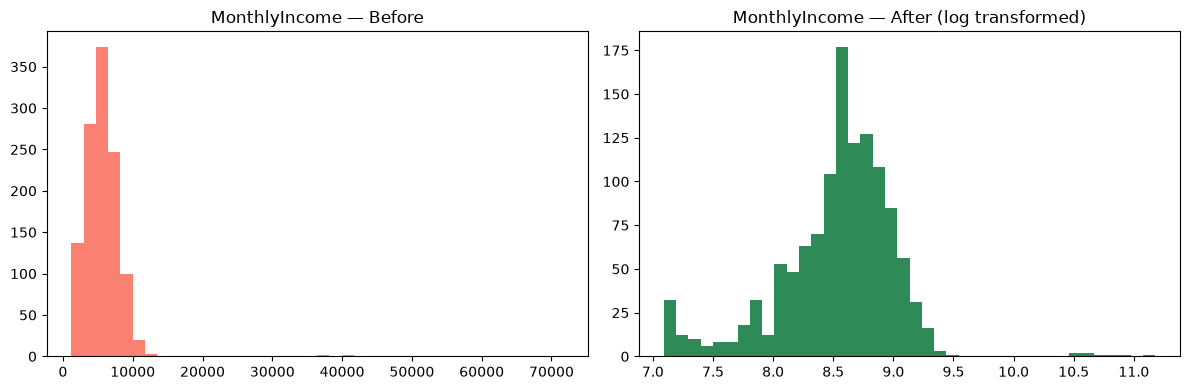

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_before["MonthlyIncome"].dropna().astype(str).str.replace(" USD", "", regex=False).astype(float), bins=40, color="salmon")
axes[0].set_title("MonthlyIncome — Before")

axes[1].hist(np.log1p(df_after["MonthlyIncome"]), bins=40, color="seagreen")
axes[1].set_title("MonthlyIncome — After (log transformed)")

plt.tight_layout()
plt.show()

## 7. Categorical Values Comparison

In [21]:
print("BEFORE Gender values:", sorted(df_before["Gender"].dropna().unique()))
print("AFTER Gender values:", sorted(df_after["Gender"].dropna().unique()))
print()
print("BEFORE Department values:", sorted(df_before["Department"].dropna().unique()))
print("AFTER Department values:", sorted(df_after["Department"].dropna().unique()))

BEFORE Gender values: ['F', 'FEMALE', 'Female', 'M', 'Male', 'male']
AFTER Gender values: ['Female', 'Male']

BEFORE Department values: ['Engineering', 'Finance', 'HR', 'Marketing', 'SALES', 'Sales', 'Sales ', 'Support', 'sales']
AFTER Department values: ['Engineering', 'Finance', 'Hr', 'Marketing', 'Sales', 'Support']


**What changed and why:** `Gender` had 6 inconsistent variants
(`'Female'`, `'FEMALE'`, `'male'`, `'M'`, `'F'`, plus nulls), standardized
down to 2 clean categories (Notebook 5, Notebook 7). `Department` had 9
variants due to casing and stray whitespace (`'sales'`, `'SALES'`,
`'Sales '`), standardized down to the true 6 departments.

## 8. Numerical Ranges Comparison (Before vs After Scaling)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
income_scaled = scaler.fit_transform(df_after[["MonthlyIncome"]])

range_comparison = pd.DataFrame({
    "Before (raw)": [df_after["MonthlyIncome"].min(), df_after["MonthlyIncome"].max()],
    "After (scaled)": [income_scaled.min().round(2), income_scaled.max().round(2)]
}, index=["Min", "Max"])
range_comparison

,Before (raw),After (scaled)
Min,1200.000000,-1.13
Max,71638.178357,16.23


**What changed and why:** raw income ranged from roughly 1,200 to 71,638,
while every other numeric column (like `JobSatisfaction`, ranging 1 to 4)
sat on a completely different scale. Standardization (Notebook 8) puts
every numeric feature on a comparable range, so no single column dominates
a distance-based or gradient-based model purely due to its size.

In [23]:
categorical_cols = ["Gender", "Department", "JobRole", "Education", "OverTime"]
dummies = pd.get_dummies(df_after[categorical_cols], drop_first=True)

print("Original categorical columns:", len(categorical_cols))
print("Columns after one-hot encoding:", dummies.shape[1])

Original categorical columns: 5
Columns after one-hot encoding: 26


**What changed and why:** 5 categorical columns expanded into many more
binary columns after one-hot encoding (Notebook 7). This is expected and
necessary, since models need numeric input, but it's also exactly why
Notebook 10's feature selection step matters, more columns isn't
automatically better, especially with irrelevant ones like
`RandomSurveyCode` still lurking in the original set.